In [ ]:
!pip install uv
!uv pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 88.9 MB/s eta 0:00:00
Using Python 3.12.12 environment at: /usr
Resolved 186 packages in 1.97s
Prepared 63 packages in 4.73s
Uninstalled 5 packages in 66ms
Installed 63 packages in 381ms
 + backoff==2.2.1
 + coloredlogs==15.0.1
 + cyclopts==4.0.0
 + dataclasses-json==0.6.7
 + dnspython==2.8.0
 + email-validator==2.3.0
 + emoji==2.15.0
 + exceptiongroup==1.3.0
 + fastembed==0.7.3
 + fastmcp==2.12.5
 + filetype==1.2.0
 + groq==0.33.0
 + gunicorn==23.0.0
 + humanfriendly==10.0
 + isodate==0.7.2
 + jsonschema-path==0.3.4
 + langchain-cerebras==0.5.0
 + langchain-community==0.3.31
 + langchain-groq==0.3.8
 + langchain-nvidia-ai-endpoints==0.3.18
 + langchain-openai==0.3.35
 + langchain-qdrant==0.2.1
 + langdetect==1.0.9
 + langgraph==1.0.1
 + langgraph-checkpoint==3.0.0
 + langgraph-prebuilt==1.0.1
 + langgraph-sdk==0.2.9
 + lazy-object-proxy==1.12.0
 + loguru==0.7.3
 + marshmallow==3.26.1
 - mcp==1.18.0
 + mcp==1.16.0
 + mmh3==5.2.0




1.   define llm
2.   node 1 : get a transcript
3.   node 2 : use llm to generate MoM (first by simple ChatPromptTemplate)
4.   node 3 : END



In [ ]:
# now use LLM to generate transcript

# -- 1. define llm
from google.colab import userdata

GROQ_API_KEY = userdata.get("GROQ_API_KEY")
CEREBRAS_API_KEY = userdata.get("CEREBRAS_API_KEY")

from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
    api_key=GROQ_API_KEY
)

# Now trying using Langgraph

### MoM Schema
```
{
  "meeting_information": {
    "title": "string",
    "date": "string",
    "time": "string",
    "venue_or_platform": "string"
  },

  "attendees": {
    "present": ["string"],
    "absent": ["string"]
  },

  "agenda": [
    "string"
  ],

  "discussion_summary": [
    {
      "agenda_item": "string",
      "summary": "string"
    }
  ],

  "decisions_made": [
    "string"
  ],

  "action_items": [
    {
      "task": "string",
      "assignee": "string",
      "deadline": "string"
    }
  ],

  "next_steps": [
    "string"
  ]
}

```

In [ ]:
from typing import TypedDict, Annotated, List, Optional
from pydantic import BaseModel, Field

class MeetingInfo(BaseModel):
  title: str = Field(description='Title of the meeting.')
  date: str = Field(description='Date of the meeting, in YYYY-MM-DD')
  time: str = Field(description='Meeting start and end time')
  venue_or_platform: str = Field(description="Meeting location (Physical) or online platform")

class Attendees(BaseModel):
    present: List[str] = Field(..., description="List of attendees present")
    absent: Optional[List[str]] = Field(default_factory=list, description="List of attendees absent")

class DiscussionSummaryItem(BaseModel):
    agenda_item: str = Field(..., description="Agenda topic")
    summary: str = Field(..., description="Concise discussion summary for this agenda item")

class ActionItem(BaseModel):
    task: str = Field(..., description="Task description")
    assignee: str = Field(..., description="Person responsible for the task")
    deadline: str = Field(..., description="Task deadline (YYYY-MM-DD or natural text)")

class MinutesOfMeeting(BaseModel):
  meeting_info: MeetingInfo
  attendees: Attendees
  agenda: List[str]
  discussion_summary: List[DiscussionSummaryItem]
  action_items: List[ActionItem]

# ----State----
class MoMGraphState(TypedDict):
    raw_transcript: dict
    clean_transcript: Optional[str]
    meeting_context: Optional[dict]
    mom: Optional[MinutesOfMeeting]
    mom_markdown: Optional[str]


In [ ]:
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

mom_instructions = '''
mom_instructions = """You are Vocalog AI — a professional meeting documentation assistant.

Follow these steps carefully:

1. Review the meeting transcript and metadata:
{meeting_transcript}

2. Generate standardized Minutes of Meeting (MoM) in a concise and formal tone.

Rules:
- Keep summaries short and factual.
- Do not invent information or names.
- If a section is missing, output an empty array for it.
- Return only valid JSON — no explanations or extra text.
'''

def generate_mom(state: MoMGraphState):

  structured_llm = llm.with_structured_output(MinutesOfMeeting)

  system_message = mom_instructions.format(
      meeting_transcript=state["raw_transcript"]
  )

  # Generate MoM
  response_mom = structured_llm.invoke([SystemMessage(content=system_message)] + [HumanMessage(content="Generate Minutes of Meeting.")])

  return {'mom': response_mom}

In [ ]:
mom_markdown_instructions = """
You will receive a structured Minutes of Meeting (MoM) object in JSON format.
{structured_mom}
Convert it into a clean, professional Markdown document.

Formatting Rules:
- Follow standard Markdown syntax.
- Each section (Meeting Info, Attendees, Agenda, Discussion Summary, Action Items) must begin with the correct heading using `#`, `##`, or `###`.
- Use single blank lines between sections — no double `\\n\\n` or excessive spacing.
- Indent sub-items properly using two spaces.
- Bullets should use `-` and numbered items should use `1.`, `2.`, etc.
- Use bold (**) for field names and keep consistent capitalization.
- Maintain readability — spacing and line breaks must match natural Markdown layout.
- Output only the final Markdown text, with no code blocks, explanations, tables or JSON.
"""

def generate_markdown_mom(state: MoMGraphState):

  system_message = mom_markdown_instructions.format(
      structured_mom = state['mom']
  )

  response_markdown = llm.invoke([SystemMessage(content=system_message),
                                  HumanMessage(content='Generate structured markdown minutes of meeting')])

  return {'mom_markdown': response_markdown}

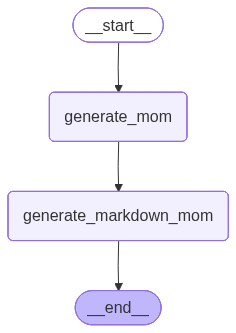

In [ ]:
from langgraph.graph import START, END, StateGraph
from IPython.display import Image, display

builder = StateGraph(MoMGraphState)

builder.add_node("generate_mom", generate_mom)
builder.add_node('generate_markdown_mom', generate_markdown_mom)

builder.add_edge(START, 'generate_mom')
builder.add_edge('generate_mom', 'generate_markdown_mom')
builder.add_edge('generate_markdown_mom', END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
sample_raw_transcript = {
  "language_code": "en",
  "language_probability": 0.99,
  "text": "Raza: Let's start with the sprint progress. Ahmed: Backend modules are almost complete, only testing remains. Hamza: Frontend integration will be done by Wednesday. Raza: Good. We'll release the build on Friday then.",
  "words": [
    # --- Speaker 0 (Raza) ---
    {"text": "Let's", "start": 0.12, "end": 0.35, "type": "word", "speaker_id": "speaker_0"},
    {"text": "start", "start": 0.36, "end": 0.65, "type": "word", "speaker_id": "speaker_0"},
    {"text": "with", "start": 0.66, "end": 0.81, "type": "word", "speaker_id": "speaker_0"},
    {"text": "the", "start": 0.82, "end": 0.91, "type": "word", "speaker_id": "speaker_0"},
    {"text": "sprint", "start": 0.92, "end": 1.25, "type": "word", "speaker_id": "speaker_0"},
    {"text": "progress.", "start": 1.26, "end": 1.65, "type": "word", "speaker_id": "speaker_0"},

    # --- Speaker 1 (Ahmed) ---
    {"text": "Backend", "start": 2.0, "end": 2.35, "type": "word", "speaker_id": "speaker_1"},
    {"text": "modules", "start": 2.36, "end": 2.72, "type": "word", "speaker_id": "speaker_1"},
    {"text": "are", "start": 2.73, "end": 2.83, "type": "word", "speaker_id": "speaker_1"},
    {"text": "almost", "start": 2.84, "end": 3.1, "type": "word", "speaker_id": "speaker_1"},
    {"text": "complete,", "start": 3.11, "end": 3.4, "type": "word", "speaker_id": "speaker_1"},
    {"text": "only", "start": 3.41, "end": 3.55, "type": "word", "speaker_id": "speaker_1"},
    {"text": "testing", "start": 3.56, "end": 3.88, "type": "word", "speaker_id": "speaker_1"},
    {"text": "remains.", "start": 3.89, "end": 4.25, "type": "word", "speaker_id": "speaker_1"},

    # --- Speaker 2 (Hamza) ---
    {"text": "Frontend", "start": 4.7, "end": 5.0, "type": "word", "speaker_id": "speaker_2"},
    {"text": "integration", "start": 5.01, "end": 5.45, "type": "word", "speaker_id": "speaker_2"},
    {"text": "will", "start": 5.46, "end": 5.58, "type": "word", "speaker_id": "speaker_2"},
    {"text": "be", "start": 5.59, "end": 5.69, "type": "word", "speaker_id": "speaker_2"},
    {"text": "done", "start": 5.7, "end": 5.9, "type": "word", "speaker_id": "speaker_2"},
    {"text": "by", "start": 5.91, "end": 6.0, "type": "word", "speaker_id": "speaker_2"},
    {"text": "Wednesday.", "start": 6.01, "end": 6.35, "type": "word", "speaker_id": "speaker_2"},

    # --- Speaker 0 (Raza again) ---
    {"text": "Good.", "start": 6.9, "end": 7.1, "type": "word", "speaker_id": "speaker_0"},
    {"text": "We'll", "start": 7.11, "end": 7.3, "type": "word", "speaker_id": "speaker_0"},
    {"text": "release", "start": 7.31, "end": 7.62, "type": "word", "speaker_id": "speaker_0"},
    {"text": "the", "start": 7.63, "end": 7.7, "type": "word", "speaker_id": "speaker_0"},
    {"text": "build", "start": 7.71, "end": 7.9, "type": "word", "speaker_id": "speaker_0"},
    {"text": "on", "start": 7.91, "end": 8.02, "type": "word", "speaker_id": "speaker_0"},
    {"text": "Friday", "start": 8.03, "end": 8.35, "type": "word", "speaker_id": "speaker_0"},
    {"text": "then.", "start": 8.36, "end": 8.55, "type": "word", "speaker_id": "speaker_0"}
  ]
}


In [ ]:
mom = graph.invoke({'raw_transcript': sample_raw_transcript})
mom['mom']

MinutesOfMeeting(meeting_info=MeetingInfo(title='Sprint Progress Meeting', date='', time='', venue_or_platform=''), attendees=Attendees(present=['Raza', 'Ahmed', 'Hamza'], absent=[]), agenda=['Sprint progress'], discussion_summary=[DiscussionSummaryItem(agenda_item='Sprint progress', summary='Raza opened the meeting. Ahmed reported that backend modules are almost complete with testing remaining. Hamza said frontend integration will be done by Wednesday. Raza confirmed that the build will be released on Friday.')], action_items=[ActionItem(task='Complete testing of backend modules', assignee='Ahmed', deadline='Friday'), ActionItem(task='Finish frontend integration', assignee='Hamza', deadline='Wednesday'), ActionItem(task='Release the build', assignee='Raza', deadline='Friday')])

In [ ]:
markdown_mom = mom['mom_markdown'].content
print(markdown_mom)

# Meeting Info
**Title:** Sprint Progress Meeting  
**Date:**  
**Time:**  
**Venue or Platform:**  

## Attendees
- **Present:**
  - Raza
  - Ahmed
  - Hamza
- **Absent:**  

## Agenda
- Sprint progress  

## Discussion Summary
- **Sprint progress:**
  - Raza opened the meeting. Ahmed reported that backend modules are almost complete with testing remaining. Hamza said frontend integration will be done by Wednesday. Raza confirmed that the build will be released on Friday.  

## Action Items
1. **Complete testing of backend modules** – **Assignee:** Ahmed – **Deadline:** Friday  
2. **Finish frontend integration** – **Assignee:** Hamza – **Deadline:** Wednesday  
3. **Release the build** – **Assignee:** Raza – **Deadline:** Friday
